# EU fuel prices, taxes & demand elasticity

Joins **EC Weekly Oil Bulletin** retail prices (with / without taxes) to **Eurostat** monthly inland deliveries, then estimates simple log–log demand elasticities across shock windows.

Futures / assessments via Bloomberg (`desk_core`):
- **Gasoline:** `GNEBM1 Index` — Eurobob oxygenated FOB Rotterdam barges (USD/t, generic M1)
- **Diesel:** `QS1 Comdty` — ICE LS Gasoil front month (USD/t)

| Shock | Window |
|-------|--------|
| COVID-19 | 2020-03 → 2021-12 |
| Russia–Ukraine | 2022-02 → 2023-09 |
| Israel–Hamas / ME risk | 2023-10 → 2023-11 |
| Red Sea / Houthi | 2023-12 → 2024-03 |
| Iran–Israel escalations | 2024-04 → 2026-01 |
| USA–Iran war | 2026-02 → present |

**Refresh retail:** `python scripts/update_eu_oil_bulletin.py`  
**Refresh demand:** `python scripts/update_eurostat.py --demand-only`

Frequency rule: keep **weekly** retail vs futures for pass-through; only average to **month** when joining Eurostat demand.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "processors").exists():
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# desk_core lives next to country_oil_scraper under Coding/
DESK_CORE = ROOT.parent / "desk_core"
sys.path.insert(0, str(DESK_CORE))
from desk_core.paths import bootstrap

bootstrap(DESK_CORE)

from desk_core.bloomberg import refdata

from analytics.units import convert_series
from reference.eu_oil_bulletin import (
    FUTURES_TICKERS,
    LARGE_MARKETS,
    METRIC_EXCISE,
    METRIC_FX,
    METRIC_OTHER_TAX,
    METRIC_PRICE_WITH_TAX,
    METRIC_PRICE_WO_TAX,
    METRIC_TAX_WEDGE,
    METRIC_VAT_RATE,
    SHOCK_WINDOWS,
)
import processors.eu_oil_bulletin as bulletin

PROCESSED = ROOT / "data" / "processed"
FUTURES_CACHE = PROCESSED / "eu_oil_bulletin" / "bloomberg_futures_daily.parquet"

# B-PIPE by default; set False if running against a local Terminal.
BBG_ON_SERVER = True
BBG_START = "2017-01-01"
BBG_END = pd.Timestamp.today().strftime("%Y-%m-%d")
INDEX_BASE = "2019-01-01"  # pass-through chart: both series = 100 here

print("ROOT:", ROOT)
print("Futures:", {k: v["ticker"] for k, v in FUTURES_TICKERS.items()})

ROOT: c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\country_oil_scraper
Futures: {'Gasoline': 'GNEBM1 Index', 'Diesel': 'QS1 Comdty'}


## 1. Weekly Oil Bulletin retail (keep weekly)

Demand stays monthly (next section). Do **not** monthly-average retail yet.

In [2]:
prices_w = bulletin.load_prices(PROCESSED)
assert prices_w is not None, "Run: python scripts/update_eu_oil_bulletin.py"

RETAIL = ["Euro-super 95", "Automotive gas oil"]
METRIC_MAP = {
    METRIC_PRICE_WITH_TAX: "price_with_tax",
    METRIC_PRICE_WO_TAX: "price_wo_tax",
    METRIC_TAX_WEDGE: "tax_wedge",
}

retail_w = prices_w[
    prices_w["metric_type"].isin(METRIC_MAP)
    & prices_w["product_native"].isin(RETAIL)
    & ~prices_w["country"].isin(["EU", "EUR"])
].copy()
retail_w["metric"] = retail_w["metric_type"].map(METRIC_MAP)
retail_w["is_large"] = retail_w["country"].isin(LARGE_MARKETS)

# Wide weekly country × product panel
retail_wide = (
    retail_w.pivot_table(
        index=[
            "date", "country", "country_id", "country_name",
            "product_native", "product_canonical", "unit", "is_large",
        ],
        columns="metric",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
)
retail_wide["date"] = pd.to_datetime(retail_wide["date"]).dt.normalize()

print(
    f"Weekly retail: {len(retail_wide):,} rows | "
    f"{retail_wide['date'].min().date()} → {retail_wide['date'].max().date()} | "
    f"{retail_wide['date'].nunique()} bulletin weeks"
)
retail_wide.head(3)

Weekly retail: 58,618 rows | 2005-01-03 → 2026-09-07 | 1083 bulletin weeks


metric,date,country,country_id,country_name,product_native,product_canonical,unit,is_large,price_with_tax,price_wo_tax,tax_wedge
0,2005-01-03,AT,austria,Austria,Automotive gas oil,Diesel,EUR/1000l,True,859.0,405.69,453.31
1,2005-01-03,AT,austria,Austria,Euro-super 95,Gasoline,EUR/1000l,True,916.0,338.63,577.37
2,2005-01-03,BE,belgium,Belgium,Automotive gas oil,Diesel,EUR/1000l,True,891.0,403.45,487.55


## 2. Eurostat demand (monthly) → kbd

Source: Eurostat `nrg_cb_oilm` gross inland deliveries (`GID_OBS`), native unit **kt**.  
Convert with project densities (`analytics.units`) to **kbd**.

In [3]:
KIND = {"Gasoline": "gasoline", "Diesel": "diesel"}

demand = pd.read_parquet(
    PROCESSED / "eurostat" / "eurostat_oilm_demand.parquet",
    columns=[
        "date", "country", "country_id", "country_name",
        "product_canonical", "value", "unit",
    ],
)
demand = demand[demand["product_canonical"].isin(["Gasoline", "Diesel"])].copy()
demand["date"] = pd.to_datetime(demand["date"]).dt.normalize()
demand = demand.rename(columns={"value": "demand_kt", "unit": "demand_unit_native"})
demand["product_kind"] = demand["product_canonical"].map(KIND)
demand["demand_kbd"] = convert_series(
    demand["demand_kt"],
    from_unit="kt",
    to_unit="kbd",
    product_kind=demand["product_kind"],
    date=demand["date"],
)
demand = demand[demand["demand_kbd"] > 0].copy()

print(
    f"Demand: {len(demand):,} rows | "
    f"{demand['date'].min().date()} → {demand['date'].max().date()}"
)
demand.groupby("product_canonical")[["demand_kt", "demand_kbd"]].mean().round(1)

Demand: 13,172 rows | 2008-01-01 → 2026-07-01


,demand_kt,demand_kbd
product_canonical,,
Diesel,730.7,179.2
Gasoline,206.9,57.8


## 3. Bloomberg futures (daily) → align to bulletin weeks

Pull daily history; for each Oil Bulletin week date take the **same-day settle**, else the **previous available** business day. No monthly average here.

In [4]:
def fetch_futures_daily(
    *,
    force: bool = False,
    on_server: bool = BBG_ON_SERVER,
) -> pd.DataFrame:
    """BDH PX_LAST for configured tickers; cache to parquet."""
    if FUTURES_CACHE.exists() and not force:
        cached = pd.read_parquet(FUTURES_CACHE)
        cached["date"] = pd.to_datetime(cached["date"]).dt.normalize()
        print(f"Loaded futures cache: {FUTURES_CACHE} ({len(cached):,} rows)")
        return cached

    tickers = [meta["ticker"] for meta in FUTURES_TICKERS.values()]
    print(f"Bloomberg BDH {tickers} {BBG_START}→{BBG_END} on_server={on_server}")
    raw = refdata.hist(
        tickers, "PX_LAST", BBG_START, BBG_END, on_server=on_server
    )
    if raw.empty:
        raise RuntimeError("Bloomberg returned no futures rows — check session / tickers")

    raw["date"] = pd.to_datetime(raw["date"]).dt.normalize()
    ticker_to_product = {v["ticker"]: k for k, v in FUTURES_TICKERS.items()}
    raw["product_canonical"] = raw["ticker"].map(ticker_to_product)
    raw = raw.rename(columns={"value": "futures_usd_t"})
    out = raw[["date", "ticker", "product_canonical", "futures_usd_t"]].dropna()
    FUTURES_CACHE.parent.mkdir(parents=True, exist_ok=True)
    out.to_parquet(FUTURES_CACHE, index=False)
    print(f"Saved {FUTURES_CACHE} ({len(out):,} rows)")
    return out


def align_to_bulletin_weeks(
    futures_daily: pd.DataFrame, bulletin_dates: pd.DatetimeIndex
) -> pd.DataFrame:
    """Map each bulletin week to last available futures settle on/before that date."""
    frames = []
    weeks = pd.DatetimeIndex(sorted(pd.to_datetime(bulletin_dates).unique()))
    for prod, g in futures_daily.groupby("product_canonical"):
        s = (
            g.sort_values("date")
            .drop_duplicates("date", keep="last")
            .set_index("date")["futures_usd_t"]
            .astype(float)
        )
        # asof: bulletin week ← prior/equal futures date
        aligned = pd.merge_asof(
            pd.DataFrame({"date": weeks}),
            s.rename("futures_usd_t").reset_index(),
            on="date",
            direction="backward",
        )
        aligned["product_canonical"] = prod
        aligned["ticker"] = FUTURES_TICKERS[prod]["ticker"]
        frames.append(aligned)
    return pd.concat(frames, ignore_index=True)


# force=True to re-pull from Bloomberg
futures_d = fetch_futures_daily(force=False)
futures_w = align_to_bulletin_weeks(futures_d, retail_wide["date"])
print(
    f"Weekly-aligned futures: {futures_w['date'].nunique()} weeks | "
    f"nulls={futures_w['futures_usd_t'].isna().sum()}"
)
futures_w.groupby("product_canonical").agg(
    start=("date", "min"), end=("date", "max"), n=("futures_usd_t", "count")
)

Loaded futures cache: c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\country_oil_scraper\data\processed\eu_oil_bulletin\bloomberg_futures_daily.parquet (2,504 rows)
Weekly-aligned futures: 1083 weeks | nulls=591


,start,end,n
product_canonical,,,
Diesel,2005-01-03,2026-09-07,492


## 4. Pass-through — weekly retail vs weekly futures

Retail (EUR/1000l) vs futures (USD/t), both **indexed to 100** at `INDEX_BASE`.

Use `plot_pass_through(countries=...)` with `"large"`, `"DE"`, or `["DE","FR","IT"]`.


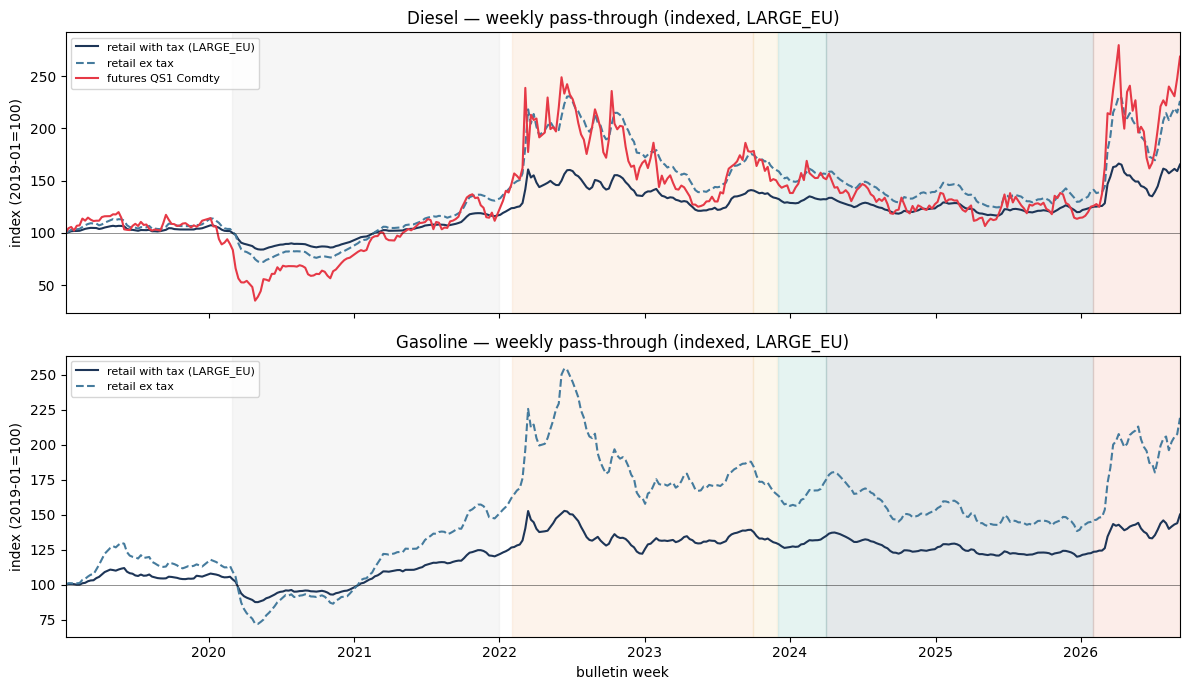

product_canonical
Diesel      392
Gasoline    392
dtype: int64

In [5]:
def _resolve_countries(countries) -> list[str] | None:
    """None = demand-weighted LARGE_MARKETS aggregate; else list of bulletin geo codes."""
    if countries is None or countries == "large":
        return None
    if countries == "all":
        return sorted(retail_wide["country"].unique())
    if isinstance(countries, str):
        return [countries]
    return list(countries)


def _scope_label(countries) -> str:
    resolved = _resolve_countries(countries)
    if resolved is None:
        return "LARGE_EU"
    if len(resolved) == 1:
        return resolved[0]
    return "+".join(resolved)


def _shock_colors() -> dict[str, str]:
    return {
        "covid": "#bbbbbb",
        "russia_ukraine": "#f4a261",
        "israel_hamas": "#e9c46a",
        "red_sea": "#2a9d8f",
        "iran_israel": "#264653",
        "usa_iran": "#e76f51",
    }


def _shade_shocks(ax, data_xmax):
    colors = _shock_colors()
    for w in SHOCK_WINDOWS:
        end = pd.Timestamp(w["end"]) if w.get("end") is not None else data_xmax
        ax.axvspan(
            pd.Timestamp(w["start"]),
            min(end, data_xmax),
            alpha=0.12,
            color=colors.get(w["id"], "#999"),
        )


def weekly_retail_agg(
    metric: str = "price_with_tax",
    countries="large",
) -> pd.DataFrame:
    """Demand-weight weekly retail for a country / group (EUR/1000l liquids)."""
    resolved = _resolve_countries(countries)
    if resolved is None:
        sl = retail_wide[retail_wide["is_large"]].copy()
    else:
        sl = retail_wide[retail_wide["country"].isin(resolved)].copy()
    sl = sl[sl["unit"].eq("EUR/1000l")]
    dem = demand[["date", "country_id", "product_canonical", "demand_kbd"]].rename(
        columns={"date": "month"}
    )
    sl["month"] = sl["date"].dt.to_period("M").dt.to_timestamp()
    sl = sl.merge(dem, on=["month", "country_id", "product_canonical"], how="left")
    rows = []
    for (dt, prod), g in sl.groupby(["date", "product_canonical"]):
        w = g["demand_kbd"].fillna(0)
        if w.sum() <= 0:
            val = g[metric].mean()
        else:
            val = np.average(g[metric], weights=w)
        rows.append({"date": dt, "product_canonical": prod, "retail": float(val)})
    return pd.DataFrame(rows)


def to_index(s: pd.Series, base_date: str) -> pd.Series:
    base = pd.Timestamp(base_date)
    # first observation on/after base
    tail = s[s.index >= base].dropna()
    if tail.empty:
        return s * np.nan
    return 100.0 * s / float(tail.iloc[0])


def build_pass_through(
    countries="large",
    *,
    start: str = "2019-01-01",
    products: list[str] | None = None,
) -> pd.DataFrame:
    """Weekly retail with/wo tax + futures for the selected scope."""
    products = products or ["Gasoline", "Diesel"]
    with_tax = weekly_retail_agg("price_with_tax", countries)
    wo_tax = weekly_retail_agg("price_wo_tax", countries).rename(
        columns={"retail": "retail_ex"}
    )
    out = with_tax.merge(wo_tax, on=["date", "product_canonical"]).merge(
        futures_w[["date", "product_canonical", "futures_usd_t", "ticker"]],
        on=["date", "product_canonical"],
        how="left",  # keep retail if a futures ticker is missing
    )
    out = out[out["product_canonical"].isin(products)]
    out = out[out["date"] >= start].sort_values(["product_canonical", "date"])
    out["scope"] = _scope_label(countries)
    return out


def plot_pass_through(
    countries="large",
    *,
    start: str = "2019-01-01",
    products: list[str] | None = None,
    index_base: str = INDEX_BASE,
):
    """Indexed weekly pass-through chart for a country / group."""
    pass_w = build_pass_through(countries, start=start, products=products)
    products = products or sorted(pass_w["product_canonical"].unique())
    scope = pass_w["scope"].iloc[0] if len(pass_w) else _scope_label(countries)
    data_xmax = pass_w["date"].max()
    n = len(products)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, prod in zip(axes, products):
        g = pass_w[pass_w["product_canonical"] == prod].set_index("date")
        if g.empty:
            ax.set_title(f"{prod} — no weekly rows ({scope})")
            continue
        r_idx = to_index(g["retail"], index_base)
        x_idx = to_index(g["retail_ex"], index_base)
        ax.plot(r_idx.index, r_idx, color="#1d3557", label=f"retail with tax ({scope})")
        ax.plot(x_idx.index, x_idx, color="#457b9d", ls="--", label="retail ex tax")
        if g["futures_usd_t"].notna().any():
            f_idx = to_index(g["futures_usd_t"], index_base)
            ax.plot(
                f_idx.index,
                f_idx,
                color="#e63946",
                label=f"futures {FUTURES_TICKERS[prod]['ticker']}",
            )
        else:
            print(f"Warning: no futures for {prod} — retail only")
        _shade_shocks(ax, data_xmax)
        ax.axhline(100, color="black", lw=0.6, alpha=0.5)
        ax.set_ylabel(f"index ({index_base[:7]}=100)")
        ax.set_title(f"{prod} — weekly pass-through (indexed, {scope})")
        ax.legend(loc="upper left", fontsize=8)
        ax.set_xlim(pass_w["date"].min(), data_xmax)

    axes[-1].set_xlabel("bulletin week")
    fig.tight_layout()
    plt.show()
    return pass_w


# examples:
#   plot_pass_through("DE")
#   plot_pass_through(["DE", "FR", "IT"], start="2020-01-01")
pass_w = plot_pass_through("large", start="2019-01-01")
pass_w.groupby("product_canonical").size()


## 5. Tax composition — wedge vs excise / other / VAT

**Tax wedge** = pump with tax − pump without tax. Stack that into:
- **Excise** and **other indirect** (bulletin duties, converted to EUR via FX where needed)
- **VAT €** from the VAT % on the pump price: `with_tax × r / (1+r)`

Use `plot_tax_breakdown(...)` to pick countries and `freq="weekly"` or `"monthly"` (weekly is better for shock timing).

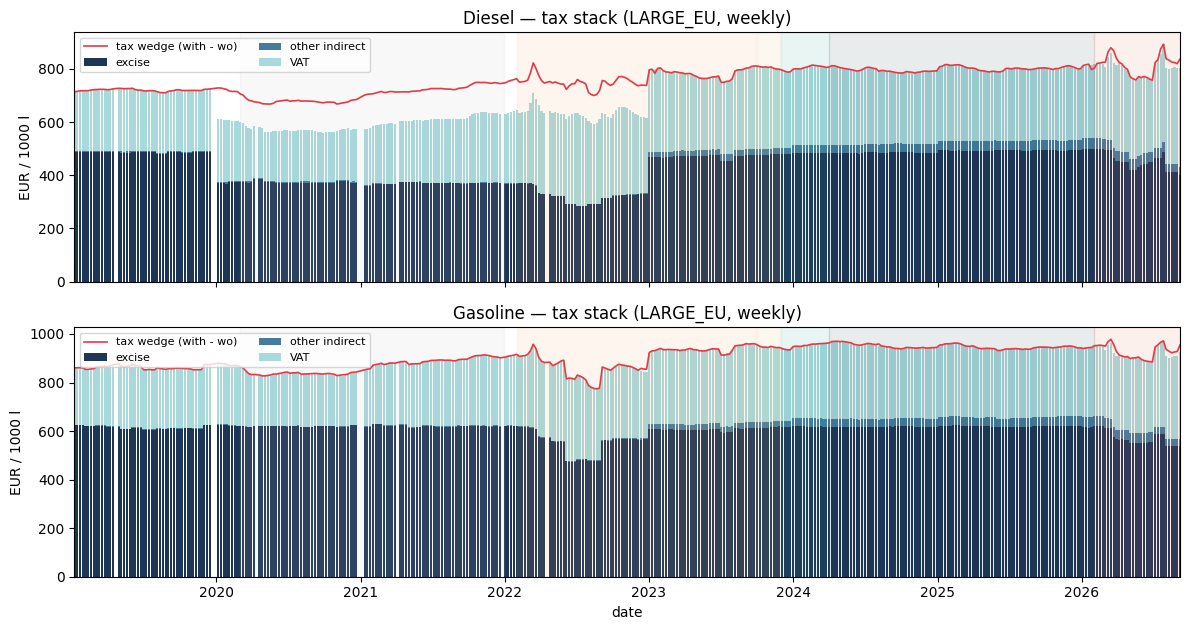

,tax_wedge,excise_eur,other_eur,vat_eur,residual
product_canonical,,,,,
Diesel,759.3,432.7,16.9,265.6,44.2
Gasoline,903.0,604.8,17.4,279.5,1.3


In [6]:
taxes_long = bulletin.load_taxes(PROCESSED)
assert taxes_long is not None, "Run: python scripts/update_eu_oil_bulletin.py"
taxes_long["date"] = pd.to_datetime(taxes_long["date"]).dt.normalize()

# EUR per national currency (euro-area geos have no FX rows → treat as 1.0)
_fx = prices_w[prices_w["metric_type"] == METRIC_FX][
    ["date", "country", "value"]
].rename(columns={"value": "fx_eur"})
_fx["date"] = pd.to_datetime(_fx["date"]).dt.normalize()


def _resolve_countries(countries) -> list[str] | None:
    """None = demand-weighted LARGE_MARKETS aggregate; else list of bulletin geo codes."""
    if countries is None or countries == "large":
        return None
    if countries == "all":
        return sorted(retail_wide["country"].unique())
    if isinstance(countries, str):
        return [countries]
    return list(countries)


def _asof_tax_metric(
    dates: pd.DatetimeIndex,
    geos: list[str],
    product: str,
    metric: str,
) -> pd.DataFrame:
    """Forward-fill sparse duty/VAT effective dates onto bulletin (or month) dates."""
    sl = taxes_long[
        (taxes_long["metric_type"] == metric)
        & (taxes_long["product_canonical"] == product)
        & (taxes_long["country"].isin(geos))
    ][["date", "country", "value"]].sort_values(["country", "date"])
    frames = []
    grid = pd.DataFrame(
        [(d, g) for g in geos for d in dates], columns=["date", "country"]
    ).sort_values(["country", "date"])
    for geo, g in grid.groupby("country", sort=False):
        left = g[["date"]].copy()
        right = sl[sl["country"] == geo][["date", "value"]]
        if right.empty:
            left["value"] = np.nan
        else:
            left = pd.merge_asof(left, right, on="date", direction="backward")
        left["country"] = geo
        frames.append(left)
    out = pd.concat(frames, ignore_index=True)
    out = out.rename(columns={"value": metric})
    return out


def _asof_fx(dates: pd.DatetimeIndex, geos: list[str]) -> pd.DataFrame:
    frames = []
    for geo in geos:
        left = pd.DataFrame({"date": dates}).sort_values("date")
        right = _fx[_fx["country"] == geo][["date", "fx_eur"]].sort_values("date")
        if right.empty:
            # already EUR (or missing FX history) — duties already in EUR terms
            left["fx_eur"] = 1.0
        else:
            left = pd.merge_asof(left, right, on="date", direction="backward")
            left["fx_eur"] = left["fx_eur"].fillna(1.0)
        left["country"] = geo
        frames.append(left)
    return pd.concat(frames, ignore_index=True)


def build_tax_breakdown(
    countries="large",
    *,
    freq: str = "weekly",
    products: list[str] | None = None,
    start: str = "2019-01-01",
) -> pd.DataFrame:
    """
    Country-level or large-EU demand-weighted tax stacks.

    Parameters
    ----------
    countries : "large" | "all" | geo code | list of geo codes
        "large" → demand-weighted LARGE_MARKETS aggregate (one series per product).
    freq : "weekly" | "monthly"
    products : default Gasoline + Diesel
    """
    if freq not in {"weekly", "monthly"}:
        raise ValueError("freq must be 'weekly' or 'monthly'")
    products = products or ["Gasoline", "Diesel"]
    resolved = _resolve_countries(countries)
    aggregate = resolved is None
    geos = (
        sorted(retail_wide.loc[retail_wide["is_large"], "country"].unique())
        if aggregate
        else resolved
    )

    retail = retail_wide[
        retail_wide["country"].isin(geos)
        & retail_wide["product_canonical"].isin(products)
        & (retail_wide["date"] >= start)
        & retail_wide["unit"].eq("EUR/1000l")
    ][
        [
            "date",
            "country",
            "product_canonical",
            "price_with_tax",
            "price_wo_tax",
            "tax_wedge",
        ]
    ].copy()
    if retail.empty:
        raise RuntimeError("No retail rows for the requested countries/products")

    # attach demand weights (monthly kbd carried onto weeks)
    dem = demand[["date", "country_id", "product_canonical", "demand_kbd"]].rename(
        columns={"date": "month"}
    )
    id_map = (
        retail_wide[["country", "country_id"]]
        .drop_duplicates()
        .set_index("country")["country_id"]
    )
    retail["country_id"] = retail["country"].map(id_map)
    retail["month"] = retail["date"].dt.to_period("M").dt.to_timestamp()
    retail = retail.merge(
        dem, on=["month", "country_id", "product_canonical"], how="left"
    )

    dates = pd.DatetimeIndex(sorted(retail["date"].unique()))
    pieces = []
    for prod in products:
        exc = _asof_tax_metric(dates, geos, prod, METRIC_EXCISE)
        oth = _asof_tax_metric(dates, geos, prod, METRIC_OTHER_TAX)
        vat = _asof_tax_metric(dates, geos, prod, METRIC_VAT_RATE)
        fx = _asof_fx(dates, geos)
        tax = (
            exc.merge(oth, on=["date", "country"], how="outer")
            .merge(vat, on=["date", "country"], how="outer")
            .merge(fx, on=["date", "country"], how="left")
        )
        tax["product_canonical"] = prod
        pieces.append(tax)
    tax_w = pd.concat(pieces, ignore_index=True)

    panel = retail.merge(tax_w, on=["date", "country", "product_canonical"], how="left")
    panel["fx_eur"] = panel["fx_eur"].fillna(1.0)
    # duties are national_currency per 1000l → EUR
    panel["excise_eur"] = panel[METRIC_EXCISE].fillna(0.0) * panel["fx_eur"]
    panel["other_eur"] = panel[METRIC_OTHER_TAX].fillna(0.0) * panel["fx_eur"]
    r = panel[METRIC_VAT_RATE].astype(float) / 100.0
    panel["vat_eur"] = panel["price_with_tax"] * r / (1.0 + r)
    panel["residual"] = (
        panel["tax_wedge"] - panel["excise_eur"] - panel["other_eur"] - panel["vat_eur"]
    )

    value_cols = [
        "price_with_tax",
        "price_wo_tax",
        "tax_wedge",
        "excise_eur",
        "other_eur",
        "vat_eur",
        "residual",
    ]

    if freq == "monthly":
        panel["date"] = panel["date"].dt.to_period("M").dt.to_timestamp()

    def _wavg(g: pd.DataFrame) -> pd.Series:
        w = g["demand_kbd"].fillna(0.0)
        out = {}
        for c in value_cols:
            if w.sum() <= 0:
                out[c] = g[c].mean()
            else:
                out[c] = np.average(g[c], weights=w)
        return pd.Series(out)

    if aggregate or len(geos) > 1:
        rows = []
        for (dt, prod), g in panel.groupby(["date", "product_canonical"]):
            rows.append({"date": dt, "product_canonical": prod, **_wavg(g).to_dict()})
        out = pd.DataFrame(rows)
        out["country"] = "LARGE_EU" if aggregate else "+".join(geos)
        out["scope"] = (
            "large_eu_demand_weighted" if aggregate else "selected_demand_weighted"
        )
    else:
        out = (
            panel.groupby(["date", "country", "product_canonical"], as_index=False)
            .apply(_wavg, include_groups=False)
            .reset_index(drop=True)
        )
        out["scope"] = "country"

    out["freq"] = freq
    return out.sort_values(["product_canonical", "date"]).reset_index(drop=True)


def plot_tax_breakdown(
    countries="large",
    *,
    freq: str = "weekly",
    products: list[str] | None = None,
    start: str = "2019-01-01",
    show_wedge_line: bool = True,
):
    """Stacked bars of excise / other / VAT; optional wedge line as check."""
    df = build_tax_breakdown(
        countries, freq=freq, products=products, start=start
    )
    products = sorted(df["product_canonical"].unique())
    n = len(products)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    colors = {
        "covid": "#bbbbbb",
        "russia_ukraine": "#f4a261",
        "israel_hamas": "#e9c46a",
        "red_sea": "#2a9d8f",
        "iran_israel": "#264653",
        "usa_iran": "#e76f51",
    }
    stack_colors = {
        "excise_eur": "#1d3557",
        "other_eur": "#457b9d",
        "vat_eur": "#a8dadc",
    }
    data_xmax = df["date"].max()
    # bar width ~80% of median spacing so weekly/monthly both read cleanly
    spans = df["date"].drop_duplicates().sort_values().diff().dropna()
    width = 0.8 * (spans.median() / pd.Timedelta(days=1)) if len(spans) else 5
    width = max(width, 1.0)

    scope = df["country"].iloc[0]
    for ax, prod in zip(axes, products):
        g = df[df["product_canonical"] == prod].sort_values("date")
        x = g["date"]
        bottoms = np.zeros(len(g))
        for col, label in [
            ("excise_eur", "excise"),
            ("other_eur", "other indirect"),
            ("vat_eur", "VAT"),
        ]:
            ax.bar(
                x,
                g[col].fillna(0.0),
                bottom=bottoms,
                width=width,
                color=stack_colors[col],
                label=label,
                align="center",
            )
            bottoms = bottoms + g[col].fillna(0.0).to_numpy()
        if show_wedge_line:
            ax.plot(
                x,
                g["tax_wedge"],
                color="#e63946",
                lw=1.2,
                label="tax wedge (with - wo)",
            )
        for w in SHOCK_WINDOWS:
            end = pd.Timestamp(w["end"]) if w.get("end") is not None else data_xmax
            ax.axvspan(
                pd.Timestamp(w["start"]),
                min(end, data_xmax),
                alpha=0.10,
                color=colors.get(w["id"], "#999"),
            )
        ax.set_ylabel("EUR / 1000 l")
        ax.set_title(f"{prod} — tax stack ({scope}, {freq})")
        ax.legend(loc="upper left", fontsize=8, ncol=2)
        ax.set_xlim(g["date"].min(), data_xmax)

    axes[-1].set_xlabel("date")
    fig.tight_layout()
    plt.show()
    return df


# defaults: large-EU weekly (shock-friendly); swap freq/countries as needed
# examples:
#   plot_tax_breakdown("DE", freq="weekly")
#   plot_tax_breakdown(["DE", "FR", "IT"], freq="monthly")
#   plot_tax_breakdown("large", freq="monthly", start="2020-01-01")
tax_stack = plot_tax_breakdown("large", freq="weekly", start="2019-01-01")
tax_stack.groupby("product_canonical")[
    ["tax_wedge", "excise_eur", "other_eur", "vat_eur", "residual"]
].mean().round(1)


## 6. Monthly panel (retail + futures + demand) for elasticity

Only here do we average weekly retail and week-aligned futures to calendar months, then join monthly `demand_kbd`.

In [7]:
# Monthly retail (country-level)
rw = retail_wide.copy()
rw["month"] = rw["date"].dt.to_period("M").dt.to_timestamp()
prices_m = (
    rw.groupby(
        [
            "month", "country", "country_id", "country_name",
            "product_native", "product_canonical", "unit", "is_large",
        ],
        as_index=False,
    )
    .agg(
        price_with_tax=("price_with_tax", "mean"),
        price_wo_tax=("price_wo_tax", "mean"),
        tax_wedge=("tax_wedge", "mean"),
    )
    .rename(columns={"month": "date"})
)

# Monthly futures from the week-aligned series (mean of bulletin weeks in month)
fw = futures_w.dropna(subset=["futures_usd_t"]).copy()
fw["month"] = fw["date"].dt.to_period("M").dt.to_timestamp()
futures_m = (
    fw.groupby(["month", "product_canonical", "ticker"], as_index=False)["futures_usd_t"]
    .mean()
    .rename(columns={"month": "date"})
)

panel = prices_m.merge(
    demand[["date", "country_id", "product_canonical", "demand_kt", "demand_kbd"]],
    on=["date", "country_id", "product_canonical"],
    how="inner",
)
panel = panel.merge(futures_m, on=["date", "product_canonical"], how="left")
panel = panel[
    (panel["demand_kbd"] > 0)
    & (panel["price_with_tax"] > 0)
    & (panel["price_wo_tax"] > 0)
].copy()

print(
    f"Monthly panel: {len(panel):,} rows | "
    f"{panel['country'].nunique()} countries | "
    f"{panel['date'].min().date()} → {panel['date'].max().date()}"
)
panel[["demand_kt", "demand_kbd", "price_with_tax", "futures_usd_t"]].describe().round(2)

Monthly panel: 11,412 rows | 27 countries | 2008-01-01 → 2026-07-01


,demand_kt,demand_kbd,price_with_tax,futures_usd_t
count,11412.00,11412.00,11412.00,3016.00
mean,490.92,124.21,1368.14,683.24
std,850.69,209.91,255.99,215.97
min,3.58,1.01,703.54,248.75
25%,69.00,17.91,1188.60,564.69
50%,164.00,42.77,1346.88,657.75
75%,432.02,109.25,1516.82,782.15
max,5784.00,1391.89,2531.25,1300.06


## 7. Shock windows

In [8]:
def assign_shock(ts: pd.Series) -> pd.Series:
    out = pd.Series("baseline", index=ts.index, dtype=object)
    for w in SHOCK_WINDOWS:
        start = pd.Timestamp(w["start"])
        # open-ended windows (end=None) include everything from start onward
        if w.get("end") is None:
            mask = ts >= start
        else:
            mask = (ts >= start) & (ts <= pd.Timestamp(w["end"]))
        out.loc[mask] = w["id"]
    return out


panel["shock"] = assign_shock(panel["date"])
panel.loc[
    (panel["date"] >= "2017-01-01") & (panel["date"] < "2020-03-01"), "shock"
] = "pre_covid"

shock_order = ["pre_covid"] + [w["id"] for w in SHOCK_WINDOWS]
panel["shock"] = pd.Categorical(panel["shock"], categories=shock_order, ordered=True)
panel["shock"].value_counts(dropna=False)

shock
NaN               5435
pre_covid         1934
iran_israel       1187
covid             1186
russia_ukraine    1062
usa_iran           284
red_sea            216
israel_hamas       108
Name: count, dtype: int64

## 8. Monthly prices & demand (by country / group)

- `plot_monthly_market(countries=...)` — prices (+ futures) and demand in separate panels
- `plot_price_demand_overlay(countries=...)` — **same chart** (indexed or dual-axis) to eyeball whether price spikes coincide with demand drops


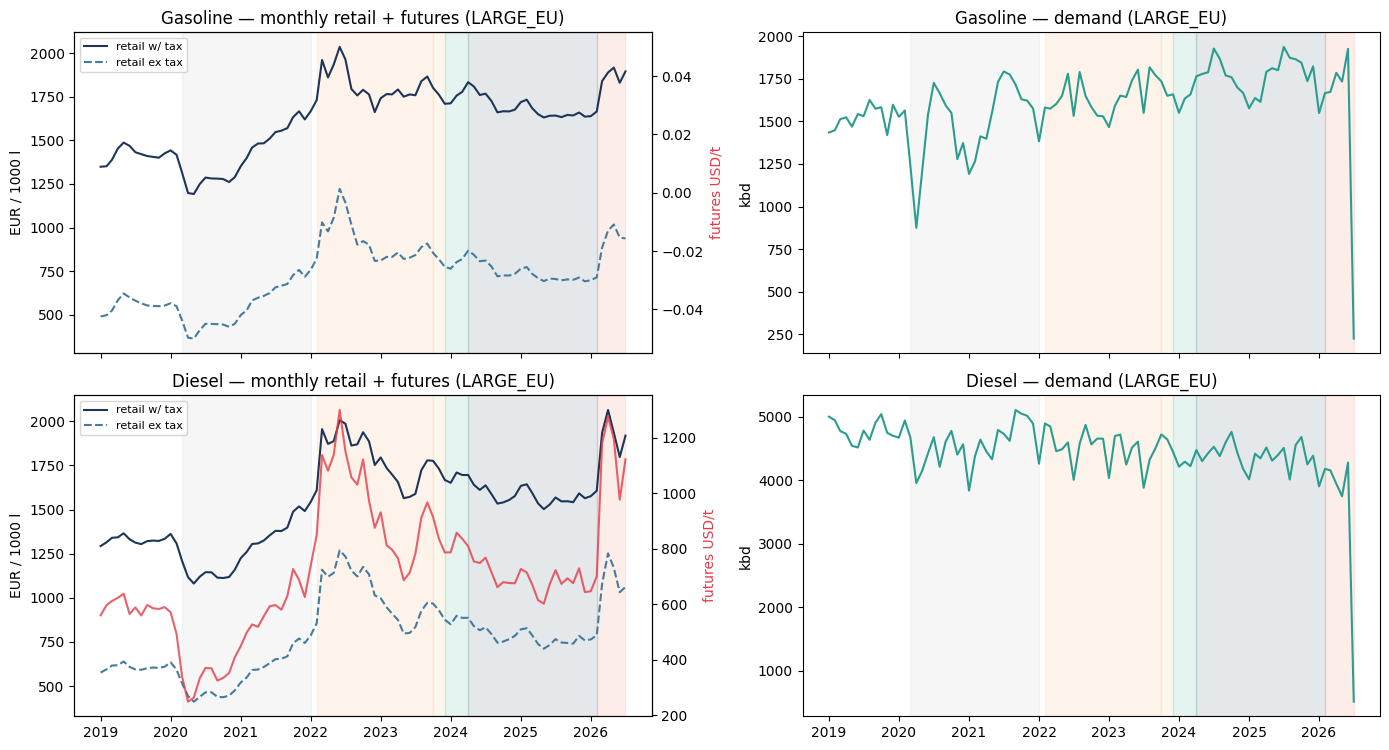

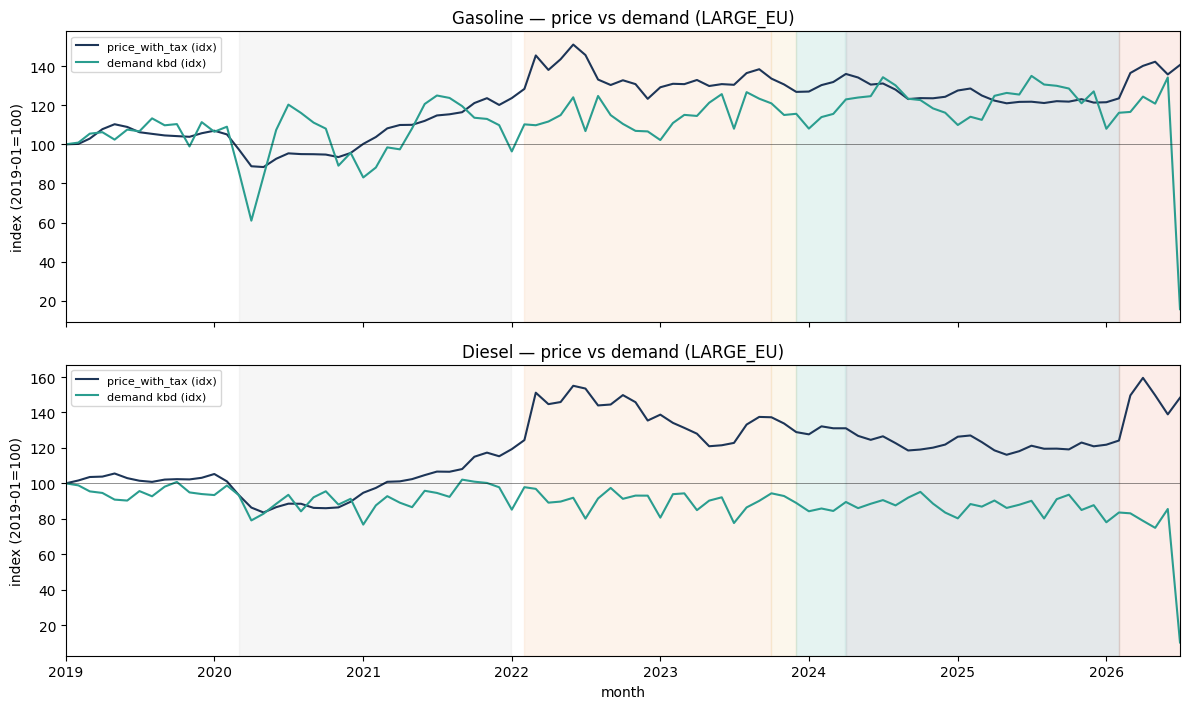

In [9]:
def _panel_scope(countries="large", start: str = "2019-01-01") -> pd.DataFrame:
    """Filter monthly elasticity panel to a country / group."""
    resolved = _resolve_countries(countries)
    sl = panel[panel["date"] >= start].copy()
    if resolved is None:
        sl = sl[sl["is_large"]]
    else:
        sl = sl[sl["country"].isin(resolved)]
    return sl


def _agg_monthly_market(sl: pd.DataFrame) -> pd.DataFrame:
    """Collapse country rows to one demand-weighted series per date × product."""

    def _agg(d):
        w = d["demand_kbd"].fillna(0)
        out = {
            "futures_usd_t": d["futures_usd_t"].mean(),
            "demand_kbd": d["demand_kbd"].sum(),
        }
        for col in ("price_with_tax", "price_wo_tax"):
            if w.sum() <= 0:
                out[col] = d[col].mean()
            else:
                out[col] = np.average(d[col], weights=w)
        return pd.Series(out)

    rows = []
    for (dt, prod), g in sl.groupby(["date", "product_canonical"]):
        rows.append({"date": dt, "product_canonical": prod, **_agg(g).to_dict()})
    return pd.DataFrame(rows)


def plot_monthly_market(
    countries="large",
    *,
    start: str = "2019-01-01",
    products: list[str] | None = None,
):
    """Prices (+ futures) and demand in separate panels — country / group selectable."""
    products = products or ["Gasoline", "Diesel"]
    focus = _panel_scope(countries, start=start)
    scope = _scope_label(countries)
    n = len(products)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.8 * n), sharex=True)
    if n == 1:
        axes = np.array([axes])

    for i, prod in enumerate(products):
        sl = focus[focus["product_canonical"] == prod]
        g = _agg_monthly_market(sl)
        axp, axd = axes[i]
        if g.empty:
            axp.set_title(f"{prod} — no rows ({scope})")
            continue
        data_xmax = g["date"].max()
        axp.plot(g["date"], g["price_with_tax"], label="retail w/ tax", color="#1d3557")
        axp.plot(
            g["date"], g["price_wo_tax"], label="retail ex tax", color="#457b9d", ls="--"
        )
        axp2 = axp.twinx()
        axp2.plot(
            g["date"],
            g["futures_usd_t"],
            label="futures USD/t",
            color="#e63946",
            alpha=0.8,
        )
        axp2.set_ylabel("futures USD/t", color="#e63946")
        _shade_shocks(axp, data_xmax)
        axp.set_title(f"{prod} — monthly retail + futures ({scope})")
        axp.set_ylabel("EUR / 1000 l")
        axp.legend(loc="upper left", fontsize=8)

        axd.plot(g["date"], g["demand_kbd"], color="#2a9d8f")
        _shade_shocks(axd, data_xmax)
        axd.set_title(f"{prod} — demand ({scope})")
        axd.set_ylabel("kbd")

    fig.tight_layout()
    plt.show()


def plot_price_demand_overlay(
    countries="large",
    *,
    start: str = "2019-01-01",
    products: list[str] | None = None,
    index_base: str | None = "2019-01-01",
    price_col: str = "price_with_tax",
):
    """
    Price and demand on one chart per product — for eyeballing demand destruction.

    If index_base is set, both series are indexed to 100 (easier to compare moves).
    If None, dual y-axes (EUR/1000l vs kbd).
    """
    products = products or ["Gasoline", "Diesel"]
    focus = _panel_scope(countries, start=start)
    scope = _scope_label(countries)
    market = _agg_monthly_market(focus)
    n = len(products)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, prod in zip(axes, products):
        g = market[market["product_canonical"] == prod].sort_values("date").set_index(
            "date"
        )
        if g.empty:
            ax.set_title(f"{prod} — no rows ({scope})")
            continue
        data_xmax = g.index.max()
        if index_base is not None:
            p_idx = to_index(g[price_col], index_base)
            q_idx = to_index(g["demand_kbd"], index_base)
            ax.plot(p_idx.index, p_idx, color="#1d3557", label=f"{price_col} (idx)")
            ax.plot(q_idx.index, q_idx, color="#2a9d8f", label="demand kbd (idx)")
            ax.axhline(100, color="black", lw=0.6, alpha=0.5)
            ax.set_ylabel(f"index ({str(index_base)[:7]}=100)")
        else:
            ax.plot(
                g.index, g[price_col], color="#1d3557", label=price_col
            )
            ax.set_ylabel("EUR / 1000 l", color="#1d3557")
            ax2 = ax.twinx()
            ax2.plot(
                g.index, g["demand_kbd"], color="#2a9d8f", label="demand kbd"
            )
            ax2.set_ylabel("kbd", color="#2a9d8f")
        _shade_shocks(ax, data_xmax)
        ax.set_title(f"{prod} — price vs demand ({scope})")
        ax.legend(loc="upper left", fontsize=8)
        ax.set_xlim(g.index.min(), data_xmax)

    axes[-1].set_xlabel("month")
    fig.tight_layout()
    plt.show()
    return market


# examples:
#   plot_monthly_market("DE")
#   plot_price_demand_overlay("DE", index_base="2019-01-01")
#   plot_price_demand_overlay(["DE", "FR"], index_base=None)  # dual axis levels
plot_monthly_market("large", start="2019-01-01")
_ = plot_price_demand_overlay("large", start="2019-01-01", index_base="2019-01-01")


## 9. Elasticity v1 — within-country demeaned log–log (kbd × pump price)

$$\widetilde{\log Q} = \beta\, \widetilde{\log P} + \varepsilon$$

`plot_elasticity(countries=...)` / `compute_elasticity(countries=...)` — `"large"`, one geo, or a list — to compare sensitivity across markets. Demand in **kbd**. No activity controls yet (COVID is still a demand shock).


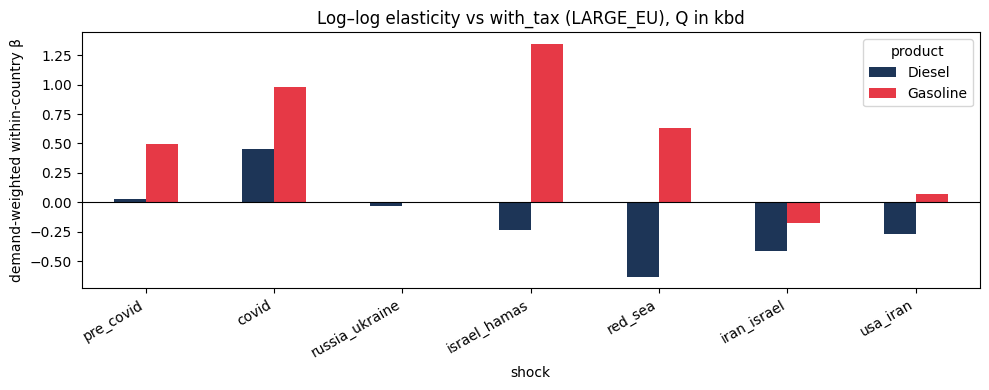

beta                  n_countries                 
price                   ex_tax futures with_tax      ex_tax futures with_tax
shock          product                                                      
covid          Diesel    0.233   0.153    0.454        17.0    17.0     17.0
               Gasoline  0.466     NaN    0.976        17.0     0.0     17.0
iran_israel    Diesel   -0.110   0.058   -0.417        17.0    17.0     17.0
               Gasoline -0.041     NaN   -0.179        17.0     0.0     17.0
israel_hamas   Diesel   -0.196   0.180   -0.234        17.0    17.0     17.0
               Gasoline  0.717     NaN    1.346        17.0     0.0     17.0
pre_covid      Diesel    0.012  -0.004    0.026        17.0    17.0     17.0
               Gasoline  0.252     NaN    0.492        17.0     0.0     17.0
red_sea        Diesel    0.607  -0.169   -0.632        17.0    17.0     17.0
               Gasoline  0.832     NaN    0.628        17.0     0.0     17.0
russia_ukraine Diesel    0.021   0.037   -0.035        17.0    17.0     17.0
               Gasoline  0.068     NaN   -0.004        17.0     0.0     17.0
usa_iran       Diesel   -0.181  -0.120   -0.269        17.0    17.0     17.0
               Gasoline  0.201     NaN    0.068        17.0     0.0     17.0

In [10]:
def within_elasticity(df: pd.DataFrame, price_col: str, min_obs: int = 2) -> float | None:
    d = df.dropna(subset=["demand_kbd", price_col]).copy()
    d = d[(d["demand_kbd"] > 0) & (d[price_col] > 0)]
    if len(d) < min_obs:
        return None
    y = np.log(d["demand_kbd"].to_numpy())
    x = np.log(d[price_col].to_numpy())
    y = y - y.mean()
    x = x - x.mean()
    denom = (x * x).sum()
    if denom <= 0:
        return None
    return float((x * y).sum() / denom)


def compute_elasticity(
    countries="large",
    *,
    start: str | None = None,
    products: list[str] | None = None,
    price_cols: list[tuple[str, str]] | None = None,
) -> pd.DataFrame:
    """
    Within-country demeaned log–log β by shock, demand-weighted across selected geos.

    countries="DE" → that country's β only.
    countries="large" / list → demand-weighted average of country βs in the scope.
    """
    products = products or ["Gasoline", "Diesel"]
    price_cols = price_cols or [
        ("price_with_tax", "with_tax"),
        ("price_wo_tax", "ex_tax"),
        ("futures_usd_t", "futures"),
    ]
    resolved = _resolve_countries(countries)
    base = panel.copy()
    if start is not None:
        base = base[base["date"] >= start]
    if resolved is None:
        base = base[base["is_large"]]
    else:
        base = base[base["country"].isin(resolved)]

    rows = []
    for shock in shock_order:
        for prod in products:
            for price_col, price_label in price_cols:
                betas, wts = [], []
                sl = base[
                    (base["shock"] == shock) & (base["product_canonical"] == prod)
                ]
                for _, gg in sl.groupby("country_id"):
                    b = within_elasticity(gg, price_col)
                    if b is None:
                        continue
                    betas.append(b)
                    wts.append(float(gg["demand_kbd"].mean()))
                beta = float(np.average(betas, weights=wts)) if betas else np.nan
                rows.append(
                    {
                        "shock": shock,
                        "product": prod,
                        "price": price_label,
                        "beta": beta,
                        "n_countries": len(betas),
                        "scope": _scope_label(countries),
                    }
                )
    return pd.DataFrame(rows)


def plot_elasticity(
    countries="large",
    *,
    price: str = "with_tax",
    start: str | None = None,
):
    """Bar chart of within-country β by shock for the selected scope."""
    elas = compute_elasticity(countries, start=start)
    scope = elas["scope"].iloc[0] if len(elas) else _scope_label(countries)
    view = (
        elas[elas["price"] == price]
        .pivot(index="shock", columns="product", values="beta")
        .reindex(shock_order)
    )
    ax = view.plot(kind="bar", figsize=(10, 4), color=["#1d3557", "#e63946"])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("demand-weighted within-country β")
    ax.set_title(f"Log–log elasticity vs {price} ({scope}), Q in kbd")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    return elas


# examples:
#   plot_elasticity("DE")
#   plot_elasticity(["DE", "FR", "IT"])
#   elas_de = compute_elasticity("DE"); elas_fr = compute_elasticity("FR")
elas = plot_elasticity("large")
elas.pivot_table(
    index=["shock", "product"], columns="price", values=["beta", "n_countries"]
).round(3)


## Next iterations

1. Convert futures USD/t → EUR/1000l (FX + density) for a levels pass-through, not just indexed.
2. Lag retail vs futures by 1–4 weeks.
3. Seasonally adjust demand; activity controls for COVID.
4. Re-pull futures: set `force=True` in `fetch_futures_daily`.